In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.optimize as sco
import os

# --- 1. Project Directory Setup ---
data_dir = 'raw_data_week3'
if not os.path.exists(data_dir):
    os.makedirs(data_dir)
    print(f"Created directory: {data_dir}")

# --- 2. Universe Definition ---
# 50 Stocks + 1 Benchmark. Fixed ABBV and refined for sector dispersion.
tickers = [
    'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA', 'TSLA', 'BRK-B', 'V', 'UNH',
    'JNJ', 'XOM', 'WMT', 'PG', 'JPM', 'MA', 'LLY', 'CVX', 'HD', 'ABBV',
    'ORCL', 'KO', 'PEP', 'BAC', 'AVGO', 'COST', 'ADI', 'GS', 'BLK', 'LMT',
    'AMT', 'EQIX', 'ISRG', 'MDT', 'TJX', 'PFE', 'ABT', 'DIS', 'NFLX', 'CAT',
    'UPS', 'HON', 'TXN', 'MS', 'NEE', 'PM', 'RTX', 'LOW', 'AMGN', 'INTC'
]
benchmark = '^GSPC'
start_date, end_date = '2016-01-01', '2026-03-25'

print("Environment initialized.")

Environment initialized.


In [2]:
# --- 1. Downloading Adjusted Close Prices ---
print(f"Downloading data for {len(tickers)} assets...")
raw_data = yf.download(tickers + [benchmark], start=start_date, end=end_date, auto_adjust=False)

# Securely extract Adj Close or Close
if 'Adj Close' in raw_data.columns.get_level_values(0):
    prices_all = raw_data['Adj Close']
else:
    prices_all = raw_data['Close']

# --- 2. Cleaning & Saving ---
# Keep tickers with >90% data history
valid_prices = prices_all.dropna(axis=1, thresh=len(prices_all)*0.9).ffill().bfill()
available_stocks = [t for t in tickers if t in valid_prices.columns]

# Save Raw Data to Folder
valid_prices.to_csv(os.path.join(data_dir, 'prices_50_stocks.csv'))

# --- 3. Return Matrix Calculation ---
# Simple returns for Portfolio arithmetic; Log returns for statistical stability
simple_returns = valid_prices[available_stocks].pct_change().dropna()
log_returns = np.log(valid_prices[available_stocks] / valid_prices[available_stocks].shift(1)).dropna()
bench_returns = valid_prices[benchmark].pct_change().dropna()

print(f"Data saved to /{data_dir}. Stocks available: {len(available_stocks)}")

[*********************100%***********************]  51 of 51 completed


Data saved to /raw_data_week3. Stocks available: 50


<Figure size 1500x1200 with 0 Axes>

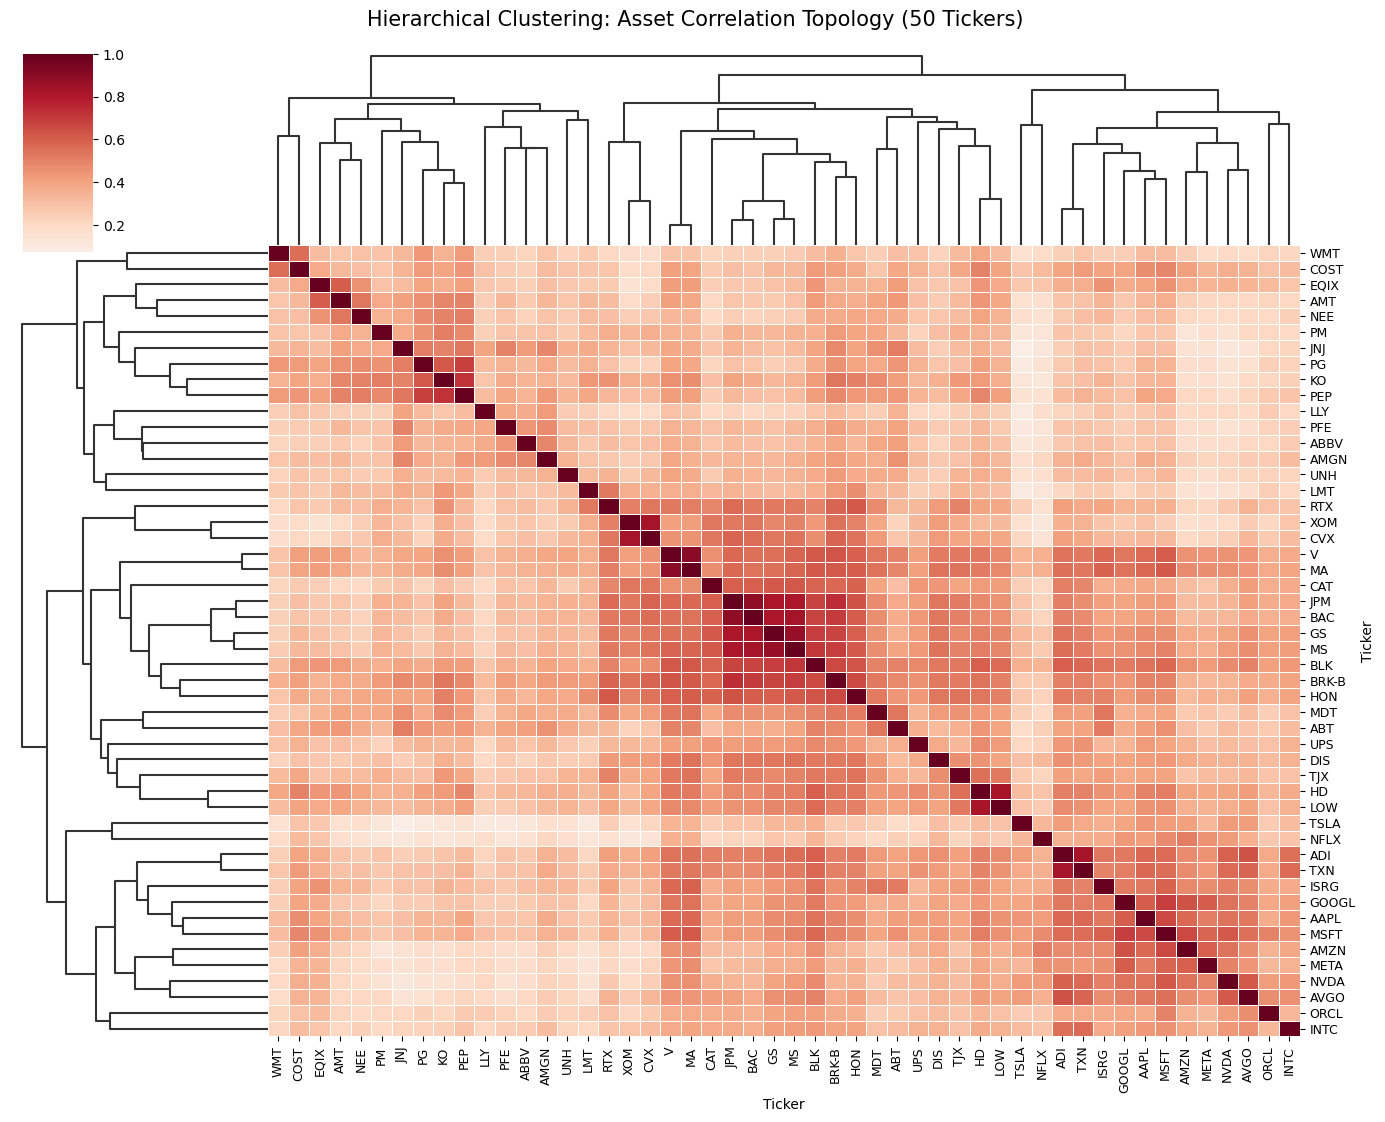

------------------------------
RISK DIAGNOSTICS SUMMARY
------------------------------
Portfolio Beta (vs S&P 500): 0.9531
Diversification Ratio (DR):   1.6325
Annualized Portfolio Vol:    17.53%
------------------------------


In [3]:
# --- Task 1: Correlation Topology & Sector Clustering ---

# --- 1. Statistical Estimation ---
# We use log returns for correlation to ensure time-additivity and normality
corr_matrix = log_returns.corr()

# We use simple returns for covariance to maintain linear additivity for portfolio math
# Annualizing by multiplying by 252 trading days
cov_matrix = simple_returns.cov() * 252 

# --- 2. Optimized Hierarchical Clustering Visualization ---
# Force a large figure size to accommodate 50 tickers
plt.figure(figsize=(15, 12))

# Setting xticklabels and yticklabels to True forces Seaborn to render every ticker name
g = sns.clustermap(
    corr_matrix, 
    cmap='RdBu_r', 
    center=0, 
    annot=False, 
    linewidths=.5,
    figsize=(14, 11),
    xticklabels=True,  # Force all X-axis labels
    yticklabels=True,  # Force all Y-axis labels
    tree_kws=dict(linewidths=1.5) # Thicker dendrogram lines for better visibility
)

# Refine tick label aesthetics: 90-degree rotation for X-axis, small font for clarity
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=9)
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=9)

plt.suptitle('Hierarchical Clustering: Asset Correlation Topology (50 Tickers)', y=1.02, fontsize=15)
plt.show()

# --- 3. Portfolio Risk Benchmarking (Equal-Weight) ---
# Defining the 1/N weight vector
weights_ew = np.repeat(1/len(available_stocks), len(available_stocks))

# Calculating daily returns for the EW portfolio
port_rets_ew = simple_returns.dot(weights_ew)

# Beta Calculation: Cov(Rp, Rm) / Var(Rm)
# Aligned with the S&P 500 benchmark returns
common_idx = port_rets_ew.index.intersection(bench_returns.index)
beta = np.cov(port_rets_ew.loc[common_idx], bench_returns.loc[common_idx])[0, 1] / bench_returns.loc[common_idx].var()

# Diversification Ratio (DR): Weighted Average Vol / Portfolio Vol
# This measures the 'diversification benefit' harvested from non-perfect correlation
individual_vols = simple_returns.std() * np.sqrt(252)
weighted_avg_vol = np.sum(weights_ew * individual_vols)
portfolio_vol = port_rets_ew.std() * np.sqrt(252)
dr = weighted_avg_vol / portfolio_vol

print("-" * 30)
print("RISK DIAGNOSTICS SUMMARY")
print("-" * 30)
print(f"Portfolio Beta (vs S&P 500): {beta:.4f}")
print(f"Diversification Ratio (DR):   {dr:.4f}")
print(f"Annualized Portfolio Vol:    {portfolio_vol:.2%}")
print("-" * 30)

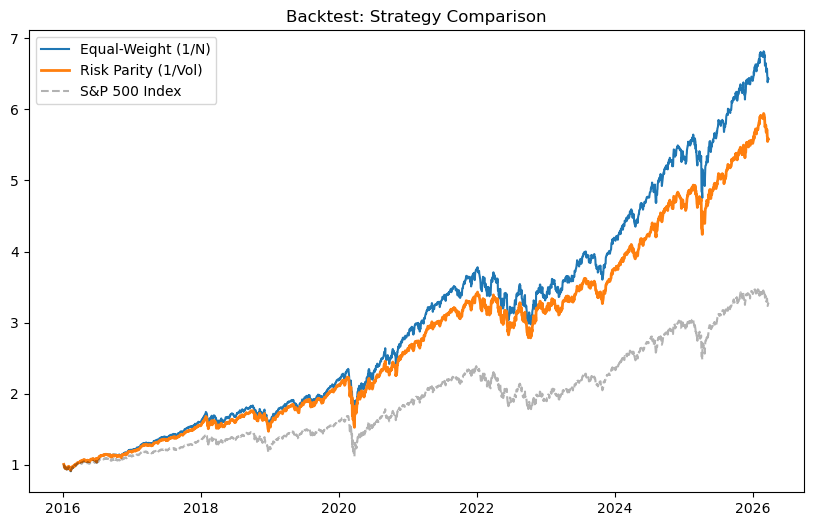

In [4]:
# --- Task 2: Heuristic Strategies - Risk Parity vs. Equal Weight ---

# --- 1. Weight Derivation ---
vols = simple_returns.std() * np.sqrt(252)
inv_vols = 1 / vols
weights_rp = inv_vols / inv_vols.sum()

# --- 2. Cumulative Returns ---
cum_ew = (1 + port_rets_ew).cumprod()
cum_rp = (1 + simple_returns.dot(weights_rp)).cumprod()
cum_bench = (1 + bench_returns.loc[port_rets_ew.index]).cumprod()

# --- 3. Performance Plot ---
plt.figure(figsize=(10, 6))
plt.plot(cum_ew, label='Equal-Weight (1/N)')
plt.plot(cum_rp, label='Risk Parity (1/Vol)', linewidth=2)
plt.plot(cum_bench, label='S&P 500 Index', color='black', alpha=0.3, linestyle='--')
plt.title('Backtest: Strategy Comparison')
plt.legend()
plt.show()

Running MVO Optimizers (this may take a few seconds)...
Simulating 100000 portfolios with Dirichlet mixed-sampling...


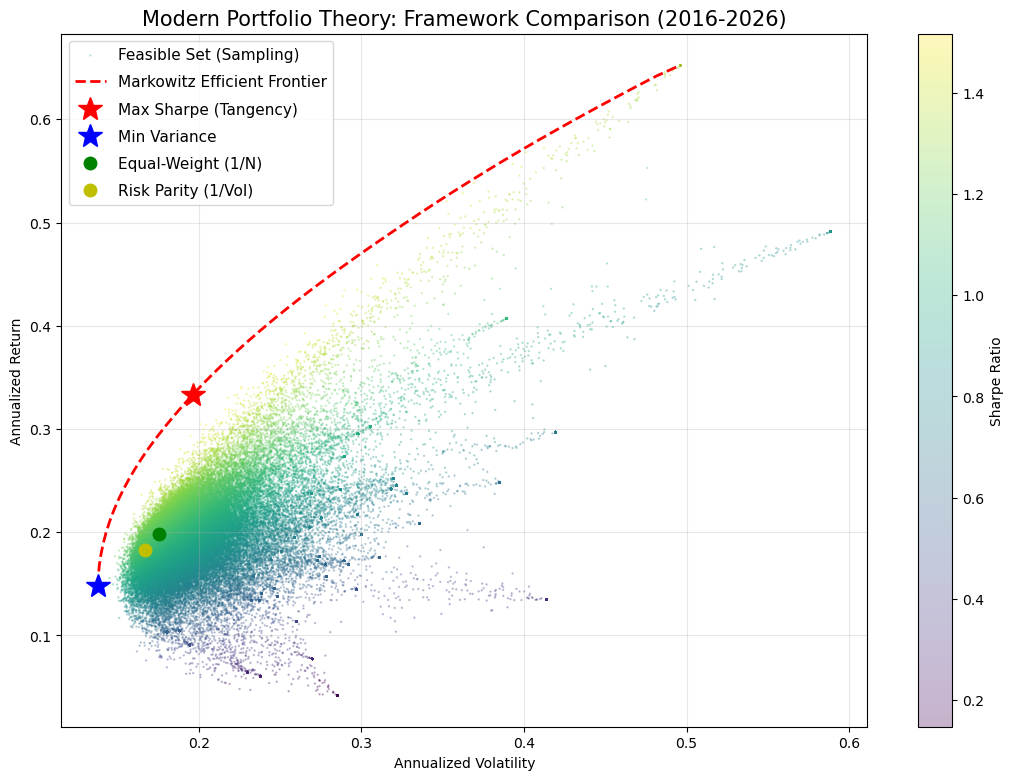

Full analysis complete.


In [5]:
# --- Task 3: Complete MVO Framework & Visual Verification ---

# 1. Statistical Parameters (Annualized)
# Ensure we are using Simple Returns for MVO consistency
mu = simple_returns.mean() * 252
sigma = simple_returns.cov() * 252
num_assets = len(available_stocks)

# 2. Re-defining the sampling function to ensure it exists after restart
def generate_advanced_weights(n_assets, n_sim):
    weights = np.zeros((n_sim, n_assets))
    # 40% Dirichlet alpha=1 (Center)
    weights[:int(n_sim*0.4)] = np.random.dirichlet(np.ones(n_assets), size=int(n_sim*0.4))
    # 40% Dirichlet alpha=0.1 (Edges/Sparse)
    weights[int(n_sim*0.4):int(n_sim*0.8)] = np.random.dirichlet(np.ones(n_assets)*0.1, size=int(n_sim*0.4))
    # 20% Edge sampling (1-3 stocks)
    for i in range(int(n_sim*0.8), n_sim):
        k = np.random.choice([1, 2, 3], p=[0.5, 0.3, 0.2])
        selected = np.random.choice(n_assets, size=k, replace=False)
        weights[i, selected] = np.random.dirichlet(np.ones(k))
    return weights

# 3. Define Portfolio Stats Helper
def get_port_stats(weights):
    weights = np.array(weights)
    port_ret = np.sum(mu * weights)
    port_vol = np.sqrt(np.dot(weights.T, np.dot(sigma, weights)))
    return np.array([port_ret, port_vol, port_ret / port_vol])

# 4. Optimization (Solving for the Theoretical Frontier)
print("Running MVO Optimizers (this may take a few seconds)...")
cons = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bnds = tuple((0, 1) for _ in range(num_assets))
init_guess = num_assets * [1. / num_assets]

# A. Max Sharpe Portfolio
res_ms = sco.minimize(lambda w: -get_port_stats(w)[2], init_guess, method='SLSQP', bounds=bnds, constraints=cons)
w_ms = res_ms['x']

# B. Min Variance Portfolio
res_mv = sco.minimize(lambda w: get_port_stats(w)[1]**2, init_guess, method='SLSQP', bounds=bnds, constraints=cons)
w_mv = res_mv['x']

# 5. Advanced Mixed Sampling (The "Cloud")
n_sim = 100000  # <--- Defined BEFORE the print statement now
print(f"Simulating {n_sim} portfolios with Dirichlet mixed-sampling...")
advanced_weights = generate_advanced_weights(num_assets, n_sim)

sim_rets = np.dot(advanced_weights, mu)
# Efficiently calculate volatility for 100k rows
sim_vols = np.sqrt(np.einsum('ij,jk,ik->i', advanced_weights, sigma, advanced_weights))
sim_sharpe = sim_rets / sim_vols

# 6. Generate the Red Line (Efficient Frontier)
target_rets = np.linspace(get_port_stats(w_mv)[0], mu.max(), 50)
efficient_vols = []
for tr in target_rets:
    cons_ef = ({'type': 'eq', 'fun': lambda x: np.sum(mu * x) - tr},
               {'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    res_ef = sco.minimize(lambda w: get_port_stats(w)[1], init_guess, method='SLSQP', bounds=bnds, constraints=cons_ef)
    efficient_vols.append(res_ef['fun'])

# 7. Final Plotting
plt.figure(figsize=(13, 9))

# A. Cloud
plt.scatter(sim_vols, sim_rets, c=sim_sharpe, cmap='viridis', s=0.5, alpha=0.3, label='Feasible Set (Sampling)')

# B. Efficient Frontier Line
plt.plot(efficient_vols, target_rets, 'r--', linewidth=2, label='Markowitz Efficient Frontier')

# C. Stars & Points
plt.plot(get_port_stats(w_ms)[1], get_port_stats(w_ms)[0], 'r*', markersize=18, label='Max Sharpe (Tangency)')
plt.plot(get_port_stats(w_mv)[1], get_port_stats(w_mv)[0], 'b*', markersize=18, label='Min Variance')

# Re-calculating EW and RP weights if they were lost during restart
weights_ew = np.repeat(1/num_assets, num_assets)
vols_individual = simple_returns.std() * np.sqrt(252)
weights_rp = (1/vols_individual) / (1/vols_individual).sum()

plt.plot(get_port_stats(weights_ew)[1], get_port_stats(weights_ew)[0], 'go', markersize=9, label='Equal-Weight (1/N)')
plt.plot(get_port_stats(weights_rp)[1], get_port_stats(weights_rp)[0], 'yo', markersize=9, label='Risk Parity (1/Vol)')

plt.title('Modern Portfolio Theory: Framework Comparison (2016-2026)', fontsize=15)
plt.xlabel('Annualized Volatility')
plt.ylabel('Annualized Return')
plt.colorbar(label='Sharpe Ratio')
plt.grid(True, alpha=0.3)
plt.legend(labelspacing=0.8, fontsize=11)
plt.show()

print("Full analysis complete.")

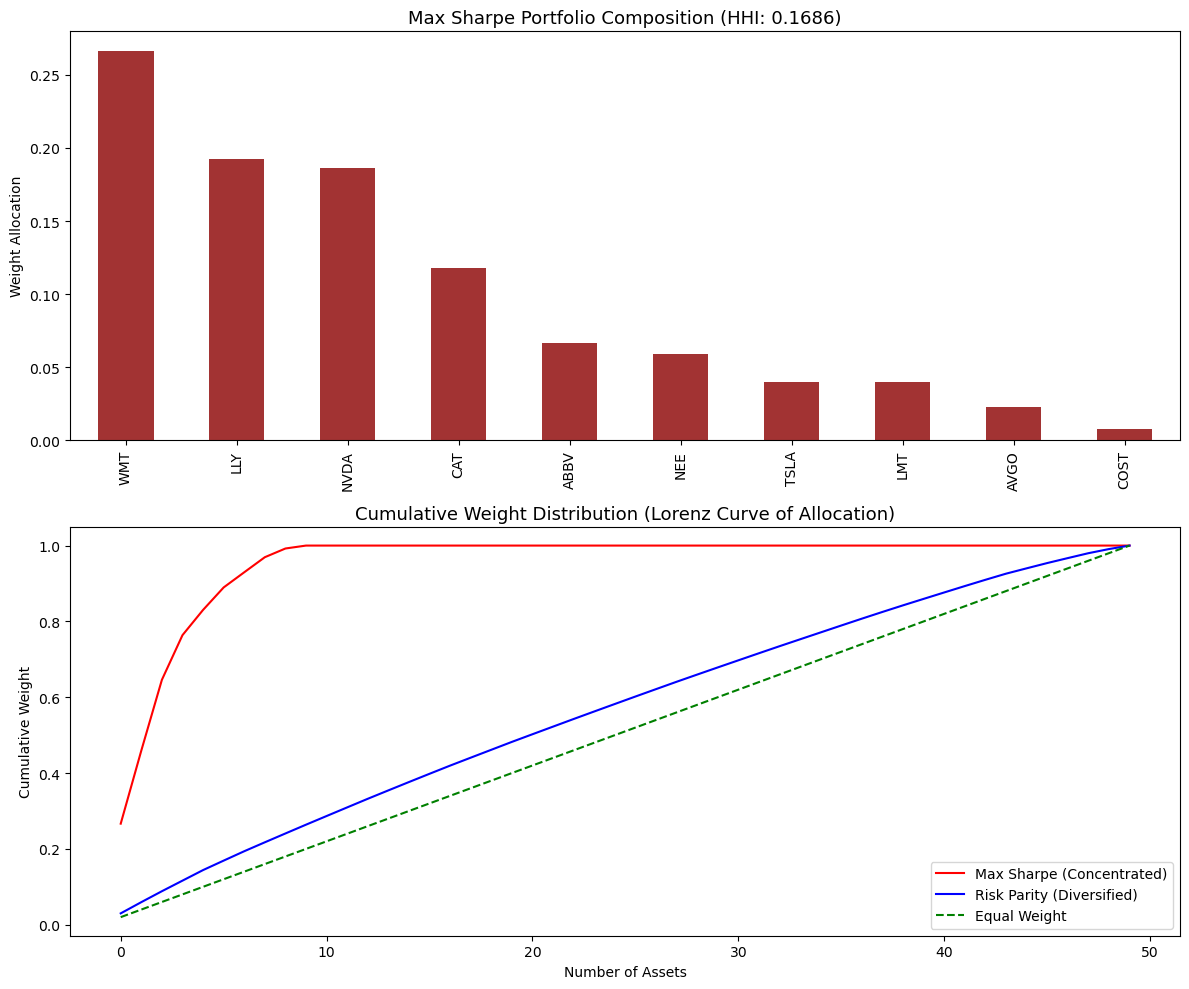

HHI Summary: Max Sharpe (0.1686) | Risk Parity (0.0210) | Equal Weight (0.0200)


In [6]:
 # --- Task 4: Portfolio Architecture & Risk Concentration ---

# 1. Extract Weights for Max Sharpe and Risk Parity
ws_ms = pd.Series(res_ms['x'], index=available_stocks)
ws_rp = pd.Series(weights_rp, index=available_stocks)

# Filter out near-zero weights for clarity (> 0.5%)
significant_ms = ws_ms[ws_ms > 0.005].sort_values(ascending=False)

# 2. Calculate Concentration Metric: Herfindahl-Hirschman Index (HHI)
# HHI = sum(w^2). Lower is more diversified. 1/N portfolio has HHI = 1/N.
hhi_ms = np.sum(ws_ms**2)
hhi_rp = np.sum(ws_rp**2)
hhi_ew = np.sum(weights_ew**2)

# 3. Visualization: Weight Comparison
fig, ax = plt.subplots(2, 1, figsize=(12, 10))

# Plot A: Max Sharpe Top Holdings
significant_ms.plot(kind='bar', ax=ax[0], color='darkred', alpha=0.8)
ax[0].set_title(f'Max Sharpe Portfolio Composition (HHI: {hhi_ms:.4f})', fontsize=13)
ax[0].set_ylabel('Weight Allocation')

# Plot B: Weight Distribution Comparison (Lorentz-style)
sorted_ms = np.sort(ws_ms)[::-1]
sorted_rp = np.sort(ws_rp)[::-1]
ax[1].plot(np.cumsum(sorted_ms), label='Max Sharpe (Concentrated)', color='red')
ax[1].plot(np.cumsum(sorted_rp), label='Risk Parity (Diversified)', color='blue')
ax[1].plot(np.cumsum(np.sort(weights_ew)[::-1]), label='Equal Weight', color='green', linestyle='--')
ax[1].set_title('Cumulative Weight Distribution (Lorenz Curve of Allocation)', fontsize=13)
ax[1].set_xlabel('Number of Assets')
ax[1].set_ylabel('Cumulative Weight')
ax[1].legend()

plt.tight_layout()
plt.show()

print(f"HHI Summary: Max Sharpe ({hhi_ms:.4f}) | Risk Parity ({hhi_rp:.4f}) | Equal Weight ({hhi_ew:.4f})")